## 1. Load data

Load from the complete dataset in `data/raw/tennis_atp-master/` (main-tour singles). (You can subset by *year range* or *max_rows* if the full set is too large)

If no local data is found, we attempt to download a sample from Jeff Sackmann's GitHub.

In [1]:
import os # Provides OS related functions like file handling
import gc # Garbage collection library (helps free unused memory)
import sys # Gives access to python system-level functions and paths
from pathlib import Path # To handle file and folder paths
import numpy as np # Numerical computing library
import pandas as pd # Data analysis library for tables/dataframes
from datetime import datetime # Date/time handling
from sklearn.model_selection import TimeSeriesSplit # For time-aware model splitting
from sklearn.preprocessing import StandardScaler # Standardizes numerical features
from sklearn.linear_model import LogisticRegression # Logistic Regression classifier
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss # Evaluation metrics
import lightgbm as lgb # Gradient boosting ML library
import joblib # Helps save and load trained models/scalers

# Add project root for src imports (adds current project directory to python's module search path;without this python may not be able to find the custom files in src folder)
sys.path.insert(0, str(Path().resolve()))

# Import custom functions written in the project
from src.data_loader import load_atp_matches # imports custom function that loads ATP match files
from src.preprocessing import clean_matches # imports custom cleaning function that standardizes the dataset
from src.features import add_elo_features, add_rolling_features, add_h2h_features, build_diff_dataset, add_elo_spec_column, ELO_SPEC_ID # Feature engineering functions that builds Elo ratings, recent form features, head-to-head features & prepares the final model dataset  

RANDOM_SEED = 42 # Fixed seed for reproducibility
np.random.seed(RANDOM_SEED) # Applies the seed to NumPy's random generator

DATA_DIR = Path('data') # Create path object for main data folder
RAW_DIR = DATA_DIR / 'raw' # Create path for raw data subfolder
RAW_DIR.mkdir(parents=True, exist_ok=True) # Creates folder if it doesn't exist

# Configuration to limit the dataset size for faster execution (use last N years only or cap rows)
YEAR_MIN = 2015          # Only include matches from 2015
YEAR_MAX = None          # None = no upper bound
MAX_ROWS = 100_000       # Maximum rows to load (can be slow for full history)

# Load ATP match data using custom loader 
matches = load_atp_matches(raw_dir=RAW_DIR, tennis_atp_subdir='tennis_atp-master',
                           year_min=YEAR_MIN, year_max=YEAR_MAX, max_rows=MAX_ROWS)
# If no local files found, download sample dataset from GitHub
if len(matches) == 0:
    url = 'https://raw.githubusercontent.com/JeffSackmann/tennis_atp/master/atp_matches_2024.csv' # Online dataset location
    print('No local CSVs found — downloading sample from GitHub:', url) # Message informing user that GitHub data is being used
    matches = pd.read_csv(url, low_memory=False) # Read CSV into dataframe
    matches.to_csv(RAW_DIR / 'atp_matches_2024.csv', index=False)
    print('Downloaded to', RAW_DIR / 'atp_matches_2024.csv')
matches = clean_matches(matches) # Apply cleaning & standardization so it has same expected format as locally loaded data
print('Loaded and cleaned rows:', len(matches)) # Display number of records after loading and cleaning
matches.head()  # Display first 5 rows

Loaded and cleaned rows: 27672


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2015-339,Brisbane,hard,28,A,2015-01-04,1,105357,NaN,WC,...,31.0,20.0,5.0,8.0,1.0,5.0,153.0,328.0,220.0,221.0
1,2015-339,Brisbane,hard,28,A,2015-01-04,8,105032,NaN,NaN,...,22.0,13.0,14.0,8.0,1.0,4.0,85.0,586.0,84.0,595.0
2,2015-339,Brisbane,hard,28,A,2015-01-04,12,105449,NaN,NaN,...,68.0,51.0,19.0,16.0,3.0,4.0,37.0,999.0,77.0,657.0
3,2015-339,Brisbane,hard,28,A,2015-01-04,11,106071,NaN,NaN,...,42.0,35.0,14.0,12.0,4.0,6.0,53.0,797.0,35.0,1090.0
4,2015-339,Brisbane,hard,28,A,2015-01-04,10,106423,NaN,WC,...,33.0,23.0,7.0,9.0,1.0,4.0,149.0,341.0,25.0,1365.0


**Result Explanation:** *It means the final cleaned dataset contains 27672 match rows. That is the total number of ATP matches included after applying the date and size restrictions.This is important because it confirms the dataset contains both match-level and player-result information, which are needed for feature engineering.*

## 2. Minimal cleaning & standardization

We'll keep only essential columns for the demo and ensure date and surface are normalized.

*The section doesn't perform extra cleaning directly, it confirms that the cleaning already happened inside the loading pipeline.*

In [3]:
# Cleaning (column canonicalization, fixing date format, normalizing surface values, handling rank fields) was done during loading
print('Rows after load+clean:', len(matches)) # Confirm number of rows after cleaning
matches.head() # Preview cleaned dataframe

Rows after load+clean: 27672


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2015-339,Brisbane,hard,28,A,2015-01-04,1,105357,NaN,WC,...,31.0,20.0,5.0,8.0,1.0,5.0,153.0,328.0,220.0,221.0
1,2015-339,Brisbane,hard,28,A,2015-01-04,8,105032,NaN,NaN,...,22.0,13.0,14.0,8.0,1.0,4.0,85.0,586.0,84.0,595.0
2,2015-339,Brisbane,hard,28,A,2015-01-04,12,105449,NaN,NaN,...,68.0,51.0,19.0,16.0,3.0,4.0,37.0,999.0,77.0,657.0
3,2015-339,Brisbane,hard,28,A,2015-01-04,11,106071,NaN,NaN,...,42.0,35.0,14.0,12.0,4.0,6.0,53.0,797.0,35.0,1090.0
4,2015-339,Brisbane,hard,28,A,2015-01-04,10,106423,NaN,WC,...,33.0,23.0,7.0,9.0,1.0,4.0,149.0,341.0,25.0,1365.0


**Result Explanation:** *It means the number of rows after cleaning is still 27672. So, the cleaning process didn't remove additional rows at this stage.*

## 3. Elo implementation

We'll compute an Elo rating per player using chronological updates. We'll keep a global Elo and a surface-specific Elo (hard/clay/grass).

Elo rating is a dynamic skill rating system. It starts each player at a base score, usually 1500. After each match, the winner gains points and the loser loses points. The size of the update depends on expectation. So, if a strong player beats a weak player, the change is small. If a weak player beats a strong player, the change is large.

Here, we have two Elo types:
1. global Elo: overall player strength across all surfaces
2. surface Elo: player strength on a specific surface like hard, clay or grass

This is useful because players often perform differently on different surfaces.

In [5]:
matches = add_elo_features(matches) # Add overall & surface-specific Elo ratings to each match row
print('Elo computed for matches') # Confirms the Elo feature computation finished

Elo computed for matches


In [7]:
matches['elo_surf_before_w'] # Display winner's surface-specific Elo before each match

0        1500.000000
1        1500.000000
2        1500.000000
3        1500.000000
4        1500.000000
            ...     
27667    1581.883067
27668    1538.343641
27669    1690.614865
27670    1651.085517
27671    1595.478866
Name: elo_surf_before_w, Length: 27672, dtype: float64

**Result Explanation:** *At the beginning, many values are exactly 1500. That means players initially start at the default Elo score because there is no history yet. Later values become different, which means the system has learned from previous matches. Higher Elo means the player has been performing strongly and lower Elo means weaker recent historical performance.*

## 4. Rolling features

form (last K matches win rate), surface win rate, days_since_last_match

We'll build a per-player running history and then for each match extract player-level stats (up to but not including that match).

Rolling features are features calculated from a player’s recent history, usually the last few matches.

In [9]:
# Rolling features (form, surface form, days since last) via src.features

K_FORM = 8 # rolling window size: Number of past matches to consider when computing recent form 
matches = add_rolling_features(matches, K=K_FORM) # Add rolling features (recent win rate, recent surface win rate & days since last match)
print('Rolling features added') # Confirm rolling features added

Rolling features added


In [11]:
matches['form_w'] # Display winner's recent-form value before each match

0        1.000
1        0.500
2        0.000
3        0.500
4        0.000
         ...  
27667    0.750
27668    0.500
27669    0.625
27670    0.625
27671    0.750
Name: form_w, Length: 27672, dtype: float64

**Result Explanation:** *The numbers in the results are proportions:*

1. *1.000 means the player won all of the recent matches in the rolling window*
2. *0.750 means they won 75%*
3. *0.500 means they won half*
4. *0.000 means they won none*

*It is important because it gives the current condition. Even if a player has high Elo overall, poor recent form can indicate temporary decline or fatigue.*

## 4b. Head-to-head features (Bayesian smoothing)

Add H2H win rate for winner and loser vs each other (past matches only). Smoothed with a prior so few H2H meetings don't dominate.

Head-to-head or H2H means how one player has historically performed specifically against the other player. For example, even if two players are both strong overall, one may consistently do well against the other because of play style mismatch.

In [13]:
# Add head-to-head features with Bayesian smoothing
matches = add_h2h_features(matches, prior_weight=3.0, prior_win_rate=0.5) # Adds H2H features while smoothing them
matches = add_elo_spec_column(matches, ELO_SPEC_ID)
print('H2H features added; elo_spec_id =', ELO_SPEC_ID)

H2H features added; elo_spec_id = online_K32_base1500_surface_v1


**Result Explanation:** *In this section, we used prior_weight = 3.0 and prior_win_rate = 0.5. This means the code doesn't trust very small H2H histories too much. For example, if player A defeats player B once, we shouldn't immediately assume A has a 100% true advantage. Bayesian smoothing pulls that estimate toward 0.5 until enough matches are observed. From here, each match row now has historical head-to-head information from prior meetings only.*

## 5. Build match-difference dataset

We'll create a single row per match where features are differences (winner - loser) and label=1. We'll also create a mirrored dataset (loser-winner, label=0) for model training stability.

Instead of directly using winner features and loser features separately, the we create difference features such as:
1. elo_diff = winner_elo - loser_elo
2. form_diff = winner_form - loser_form
3. rank_diff = winner_rank - loser_rank and so on.

This converts the match into a comparison between the two players.

We also created a mirrored version:
1. one row: winner minus loser with label 1
2. another row: loser minus winner with label 0

This doubles the dataset and makes the training more balanced and symmetric.

In [15]:
# Build difference dataset (includes H2H when present) via src.features

# Build modeling dataset using feature differences between 2 players
df_model, features = build_diff_dataset(matches, include_h2h=True) # Creates final training dataframe & returns the list of feature names used by the model

LGB_CATEGORICAL_COLS = [c for c in ('player_a_id', 'player_b_id') if c in features]
features_logistic = [c for c in features if c not in LGB_CATEGORICAL_COLS]

# Select feature columns for model input
X = df_model[features] # Stores only the predictor columns in X
# Select label column & convert to int type
y = df_model['label'].astype(int) # Stores target label in y, making sure it is an int (because it's binary classification)

print('Model dataset rows:', len(df_model)) # Display number of rows in final modeling dataframe
print('\nFeatures:', features) # Display the feature names being used

print('\nLightGBM categoricals:', LGB_CATEGORICAL_COLS)
print('\nLogistic (numeric only):', features_logistic)

Model dataset rows: 55344

Features: ['elo_diff', 'elo_surf_diff', 'form_diff', 'surf_form_diff', 'days_since_diff', 'is_hard', 'is_clay', 'is_grass', 'elo_a', 'elo_b', 'elo_surf_a', 'elo_surf_b', 'player_a_id', 'player_b_id', 'rank_diff', 'h2h_diff']

LightGBM categoricals: ['player_a_id', 'player_b_id']

Logistic (numeric only): ['elo_diff', 'elo_surf_diff', 'form_diff', 'surf_form_diff', 'days_since_diff', 'is_hard', 'is_clay', 'is_grass', 'elo_a', 'elo_b', 'elo_surf_a', 'elo_surf_b', 'rank_diff', 'h2h_diff']


In [17]:
y # Display target labels

0        1
1        0
2        1
3        0
4        1
        ..
55339    0
55340    1
55341    0
55342    1
55343    0
Name: label, Length: 55344, dtype: int32

In [19]:
X

,elo_diff,elo_surf_diff,form_diff,surf_form_diff,days_since_diff,is_hard,is_clay,is_grass,elo_a,elo_b,elo_surf_a,elo_surf_b,player_a_id,player_b_id,rank_diff,h2h_diff
0,0.000000,0.000000,0.500,0.500000,0.0,1,0,0,1500.000000,1500.000000,1500.000000,1500.000000,105357,105733,67.0,0.00
1,-0.000000,-0.000000,-0.500,-0.500000,-0.0,1,0,0,1500.000000,1500.000000,1500.000000,1500.000000,105733,105357,-67.0,-0.00
2,0.000000,0.000000,0.000,0.000000,0.0,1,0,0,1500.000000,1500.000000,1500.000000,1500.000000,105032,103720,-1.0,0.00
3,-0.000000,-0.000000,-0.000,-0.000000,-0.0,1,0,0,1500.000000,1500.000000,1500.000000,1500.000000,103720,105032,1.0,-0.00
4,0.000000,0.000000,-0.500,-0.500000,0.0,1,0,0,1500.000000,1500.000000,1500.000000,1500.000000,105449,104594,40.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55339,-72.776273,-23.066219,-0.125,-0.125000,-0.0,1,0,0,1686.193885,1758.970158,1667.548645,1690.614865,210150,209950,-28.0,-0.00
55340,56.912053,66.384046,0.500,0.500000,0.0,1,0,0,1670.320825,1613.408772,1651.085517,1584.701471,210506,209992,9.0,0.00
55341,-56.912053,-66.384046,-0.500,-0.500000,-0.0,1,0,0,1613.408772,1670.320825,1584.701471,1651.085517,209992,210506,-9.0,-0.00
55342,-167.538379,-110.075318,0.125,0.232143,0.0,1,0,0,1604.128480,1771.666859,1595.478866,1705.554184,211663,209950,-125.0,0.25


**Result Explanation:** *The original 27672 matches became 55344 rows,
which is exactly double, confirming the mirrored-dataset approach.*

## 6. Time-aware train/test split and baseline models

We'll use TimeSeriesSplit to keep temporal order. For simplicity we'll do a single train/validation/test split based on date index.

Logistic Regression is a simple and interpretable binary classification model. It estimates the probability that an input belongs to class 1 using a weighted sum of features passed through a sigmoid function. In simple words, each feature gets a weight, the model combines them linearly and then turns the result into a probability between 0 and 1.

The most important idea here is the time-aware split. The model is trained on earlier matches and tested on later matches. That is the correct way to evaluate a sports prediction model because future data must never influence past predictions.

Accuracy: Tells how often the predicted class was correct.

AUC: Tells how well the model ranks positives above negatives. A higher AUC means better discrimination.

Brier score: Measures probability error. Lower is better. It tells us how close predicted probabilities are to actual outcomes.

In [21]:
# Find a date split: train on first 70%, val 15%, test 15% by time

n = len(matches) # Total number of original matches

# Assign date boundaries based on chronological order: first 70% for training, next 15% for validation, final 15% for testing
train_date = matches['tourney_date'].iloc[int(0.7*n)]
val_date = matches['tourney_date'].iloc[int(0.85*n)]

# [To map df_model rows back to dates we can reconstruct indices: note we made two rows per match in chronological order, so groups of 2 correspond to same match order]

# Assign a 'match_idx' column
num_matches = len(matches) # Number of original matches
match_indices = np.repeat(np.arange(num_matches), 2) # As each original match became 2 rows in df_model, repeat each match index twice

# Safety check in case lengths don't exactly match
if len(match_indices) != len(df_model):
    # safeguard: align by truncation or repetition
    match_indices = match_indices[:len(df_model)]

# Get match dates for df_model (map each model row back to its original match date)
match_dates = matches['tourney_date'].iloc[match_indices].reset_index(drop=True)

# Create boolean masks for chronological splitting
train_mask = match_dates <= train_date
val_mask = (match_dates > train_date) & (match_dates <= val_date)
test_mask = match_dates > val_date

# Apply masks to create split datasets
X_train, y_train = X[train_mask].copy(), y[train_mask].copy()
X_val, y_val = X[val_mask].copy(), y[val_mask].copy()
X_test, y_test = X[test_mask].copy(), y[test_mask].copy()

# Display split sizes
print('Train/Val/Test sizes:', len(X_train), len(X_val), len(X_test))


# Baseline Model: logistic regression
X_train_log = X_train[features_logistic]
X_val_log = X_val[features_logistic]
X_test_log = X_test[features_logistic]

scaler = StandardScaler() # Create standardization object

# Fit scaler only on training data, then transform val & test using same scaling
X_train_s = scaler.fit_transform(X_train_log)
X_val_s = scaler.transform(X_val_log)
X_test_s = scaler.transform(X_test_log)

# Create Logistic Regression model
log = LogisticRegression(max_iter=1000)
# Train model on scaled training data
log.fit(X_train_s, y_train)

# Define reusable evaluation function
def evaluate_model(clf, Xs, ys, name='model'):o
    brier = brier_score_loss(ys, probs)  # Probability calibration quality
    print(f'{name} — acc: {acc:.4f}, auc: {auc:.4f}, brier: {brier:.4f}')
    return {'acc':acc, 'auc':auc, 'brier':brier}

# Evaluate trained logistic regression model on all splits
print('Logistic performance')
_eval_train = evaluate_model(log, X_train_s, y_train, 'Logistic (train)')
_eval_val = evaluate_model(log, X_val_s, y_val, 'Logistic (val)')
_eval_test = evaluate_model(log, X_test_s, y_test, 'Logistic (test)')

Train/Val/Test sizes: 38820 8368 8156
Logistic performance
Logistic (train) — acc: 0.7515, auc: 0.8286, brier: 0.1709
Logistic (val) — acc: 0.7487, auc: 0.8305, brier: 0.1702
Logistic (test) — acc: 0.7369, auc: 0.8128, brier: 0.1780


**Result Explanation:** *The results means that training set=38820 rows, validation set=8368 rows,
test set=8156 rows. These counts are for the doubled difference dataset, not the original match count.*

*The training, validation, and test scores are fairly close. That is a good sign meaning Logistic Regression is not severely overfitting. Accuracy around 74% is a decent baseline. AUC around 0.81 to 0.83 means the model ranks match outcomes reasonably well and Brier score around 0.17 suggests the probabilities are fairly sensible but not perfect.*

## 7. LightGBM classifier (non-lambdarank) 

Using difference features plus match-level pre-match Elo (elo_a/elo_b, elo_surf_*) and player_a_id/player_b_id as categorical features (tree-based surrogate for player heterogeneity; not a formal GLMM).

LightGBM is a gradient boosting algorithm based on decision trees. In simple terms, it builds many small decision trees where each new tree tries to correct mistakes made by earlier trees and the final prediction combines all those trees.

In [23]:
# Create LightGBM dataset objects for train & validation data
lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=LGB_CATEGORICAL_COLS)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train, categorical_feature=LGB_CATEGORICAL_COLS)

# Define LightGBM hyperparameters
params = {
    'objective': 'binary', # Tells the model that it is a binary classification task
    'metric': 'auc', # AUC used to monitor model quality
    'verbosity': -1, # Suppress detailed logs
    'boosting_type': 'gbdt', # Gradient boosted decision trees
    'learning_rate': 0.05, # Step size for each boosting iteration (controls how much each tree contributes)
    'num_leaves': 31, # Complexity of each tree
    'min_data_in_leaf': 50,
    'max_depth': 10,
    'feature_fraction': 0.9, # Use 90% of features per iteration (reduce overfitting)
    'bagging_fraction': 0.8, # Use 80% of samples per iteration (reduce overfitting)
    'bagging_freq': 1, # Perform bagging in every iteration
    'seed': RANDOM_SEED, # For reproducibility: here it allows up to 2000 boosting iterations
        }

# Train the LightGBM model
bst = lgb.train(
    params,
    lgb_train,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train','val'],
    num_boost_round=2000, # Maximum number of trees
    #early_stopping_rounds=100,
    #verbose_eval=100,
)

# Function to summarize prediction quality
def summarize_preds(name, y_true, probs):
    preds = (probs > 0.5).astype(int)  # Convert probabilities to class labels
    acc = accuracy_score(y_true, preds)
    auc = roc_auc_score(y_true, probs)
    brier = brier_score_loss(y_true, probs)
    print(f'LightGBM ({name}) — acc: {acc:.4f}, auc: {auc:.4f}, brier: {brier:.4f}')

# Generate predictions on validation & test sets
preds_val = bst.predict(X_val, num_iteration=bst.best_iteration)
preds_test = bst.predict(X_test, num_iteration=bst.best_iteration)

# Print performance metrics
summarize_preds('val', y_val, preds_val)
summarize_preds('test', y_test, preds_test)

# Repeated measures: rows are not independent (mirrored pairs + same players across time)
rows_test = df_model.loc[test_mask].copy()
rows_test['prob'] = preds_test
rows_test['brier'] = (rows_test['prob'] - rows_test['label']) ** 2
if 'player_a_id' in rows_test.columns:
    by_pid = rows_test.groupby('player_a_id', observed=True)['brier'].agg(['mean', 'count'])
    print('\nRepeated-measures diagnostic (focal player_a): distribution of per-player mean test Brier')
    print(by_pid['mean'].describe())
print('\nNote: primary evaluation uses chronological split; classical iid confidence intervals understate uncertainty here.')

LightGBM (val) — acc: 0.8476, auc: 0.9341, brier: 0.1147
LightGBM (test) — acc: 0.8217, auc: 0.9119, brier: 0.1387

Repeated-measures diagnostic (focal player_a): distribution of per-player mean test Brier
count    4.880000e+02
mean     1.384195e-01
std      1.681166e-01
min      3.494026e-09
25%      4.444773e-03
50%      9.935650e-02
75%      1.907037e-01
max      9.926468e-01
Name: mean, dtype: float64

Note: primary evaluation uses chronological split; classical iid confidence intervals understate uncertainty here.


**Result Explanation:** *Compared with Logistic Regression, Accuracy increased from about 0.74 to about 0.85, AUC increased from about 0.81 to about 0.93 and Brier score improved from about 0.17 to about 0.10. This shows LightGBM captures important non-linear relationships and feature interactions that Logistic Regression cannot.*

## 7b. Optuna hyperparameter tuning

Tune LightGBM classifier hyperparameters on the validation set (minimize Brior or maximize AUC). Uses the same time-based train/val split.

Optuna is an automatic hyperparameter optimization framework. Instead of you manually trying many values for learning rate, num leaves, regularization, and bagging fraction, Optuna intelligently searches for better settings.

It works by trying a set of parameter combinations, evaluating each one, learning which regions of the search space look promising and trying better candidates over time.

In [25]:
import optuna # Used for automatic hyperparameter optimization
from optuna.integration import LightGBMPruningCallback  # Import callback that can stop poor LightGBM trials early

# Defines function that optuna will repeatedly run for different hyperparameter combinations
def objective(trial):
    # Creates a dictionary of LightGBM hyperparameters for current trial
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.15, log=True), # Lets optuna choose learning rate between 0.02 & 0.15 on log scale
        'num_leaves': trial.suggest_int('num_leaves', 15, 63), # Lets optuna choose number of leaves in each tree between 15 & 63
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100), # Lets optuna choose minimum number of samples required in a leaf
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),  # Lets optuna choose what fraction of features to sample per iteration
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),  # Lets optuna choose what fraction of training rows to sample
        'bagging_freq': 1,
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-4, 10.0, log=True), # Lets optuna choose L1 regularization strength on log scale
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-4, 10.0, log=True), # Lets optuna choose L2 regularization strength on log scale
        'seed': RANDOM_SEED,
                }
    
    lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=LGB_CATEGORICAL_COLS) # Converts training features & labels into LightGBM dataset object
    lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train, categorical_feature=LGB_CATEGORICAL_COLS) # Converts validation set into LightGBM dataset & links it to training set
    callbacks = [LightGBMPruningCallback(trial, 'auc', 'val'), # Stops this trial early if validation AUC is poor compared with other trials
                 lgb.early_stopping(80, verbose=False) # Stops model training if validation AUC does not improve for 80 rounds
                ]
    
    # Trains a LightGBM model using the hyperparameters chosen for this trial
    model = lgb.train(params, lgb_train, # Gives the parameter dictionary & training dataset
                      valid_sets=[lgb_val], valid_names=['val'],  # Evaluates performance on validation set during training
                      num_boost_round=1500, callbacks=callbacks,) # Allows up to 1500 boosting rounds & applies the callbacks
    
    # Generates predicted probabilities on validation set using the best iteration found
    preds = model.predict(X_val, num_iteration=model.best_iteration)
    return roc_auc_score(y_val, preds)  # Returns validation AUC to optuna so it can judge how good the trial was

# Run a short study (increase n_trials for better results)
study = optuna.create_study(direction='maximize',  # Tells optuna to maximize objective value, as higher AUC is better
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED, n_startup_trials=5)) # Uses TPEsampler with fixed seed & 5 random trials

# Runs 15 different hyperparameter trials & displays a progress bar while trials are running
study.optimize(objective, n_trials=15, show_progress_bar=True)

# Prints best validation AUC found across all trials
print('Best trial AUC:', study.best_value)
# Prints hyperparameter combination that produced the best AUC
print('Best params:', study.best_params)

[I 2026-05-14 15:06:48,078] A new study created in memory with name: no-name-aca744a6-7056-47da-9feb-7ca4b3f26ccc


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-05-14 15:06:49,583] Trial 0 finished with value: 0.9474053139703651 and parameters: {'learning_rate': 0.0425378509573798, 'num_leaves': 61, 'min_data_in_leaf': 76, 'feature_fraction': 0.8394633936788146, 'bagging_fraction': 0.6624074561769746, 'lambda_l1': 0.000602521573620386, 'lambda_l2': 0.00019517224641449495}. Best is trial 0 with value: 0.9474053139703651.
[I 2026-05-14 15:06:51,109] Trial 1 finished with value: 0.9469106794891949 and parameters: {'learning_rate': 0.11454791487656053, 'num_leaves': 44, 'min_data_in_leaf': 74, 'feature_fraction': 0.608233797718321, 'bagging_fraction': 0.9879639408647978, 'lambda_l1': 1.452824663751602, 'lambda_l2': 0.0011526449540315614}. Best is trial 0 with value: 0.9474053139703651.
[I 2026-05-14 15:06:52,918] Trial 2 finished with value: 0.9461259706466225 and parameters: {'learning_rate': 0.028849479442089675, 'num_leaves': 23, 'min_data_in_leaf': 37, 'feature_fraction': 0.8099025726528951, 'bagging_fraction': 0.7727780074568463, 'lam

**Result Explanation:** *The output shows the study and ran multiple trials indicating Optuna searched for better LightGBM hyperparameters. It used validation AUC as the optimization target, pruning and early stopping made the search more efficient.*

## 8. LambdaRank approach (learning-to-rank)

This uses two rows per match but with player features instead of differences and trains objective='lambdarank'.

## 8b. SHAP explainability

TreeExplainer on the LightGBM classifier: summary plot and mean |SHAP| per feature (sample of validation set for speed).

SHAP stands for SHapley Additive exPlanations. It explains how much each feature contributes to a prediction. In simple words, for each match prediction, SHAP tells which features pushed the prediction toward "win or loss". Across many matches, SHAP shows which features matter most overall.

This is useful because boosted tree models are powerful but less interpretable than Logistic Regression.

C:\Users\Sheni Nevil\anaconda3\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\Sheni Nevil\AppData\Local\Temp\ipykernel_8828\1563094572.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val_sample, feature_names=features, show=False)


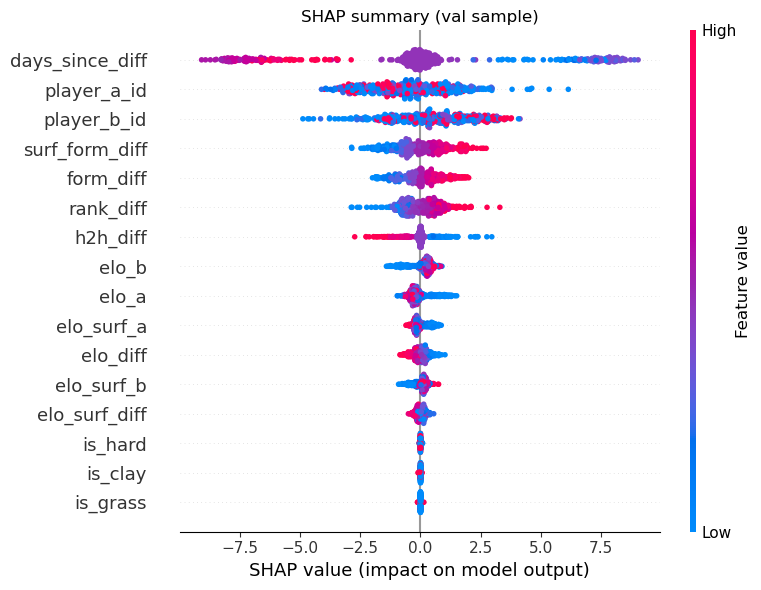

C:\Users\Sheni Nevil\AppData\Local\Temp\ipykernel_8828\1563094572.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val_sample, feature_names=features, plot_type='bar', show=False)


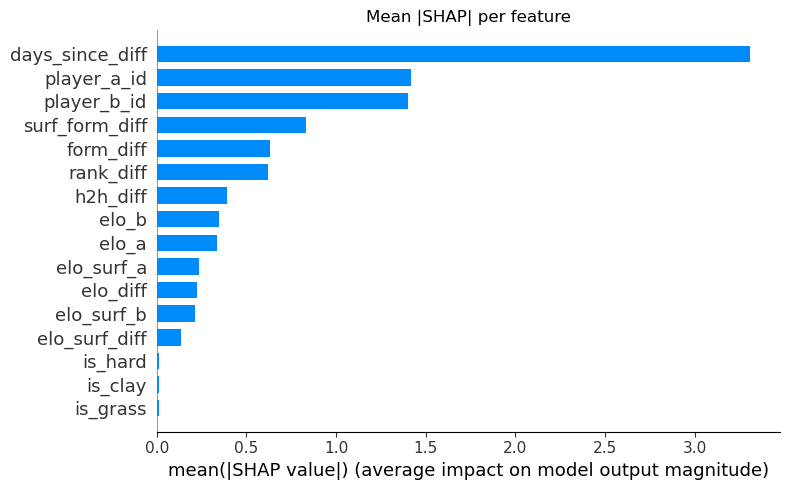

In [35]:
import matplotlib.pyplot as plt # Plotting library
import shap # For explaining model predictions 

# Use the trained LightGBM classifier (bst) & a sample of validation data
sample_size = min(500, len(X_val)) # Take upto 500 rows from validation set for SHAP analysis

# Randomly sample validation rows if possible, otherwise take the first sample_size rows
X_val_sample = X_val.sample(n=sample_size, random_state=RANDOM_SEED) if hasattr(X_val, 'sample') else X_val.iloc[:sample_size]

# Create SHAP explainer for the trained LightGBM model
explainer = shap.TreeExplainer(bst, feature_names=features)
# Compute SHAP values for the sampled validation data
shap_values = explainer.shap_values(X_val_sample)

# For binary classification, SHAP return values for both classes, so store the positive-class values
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # positive class for binary

# Summary plot (beeswarm plot)
shap.summary_plot(shap_values, X_val_sample, feature_names=features, show=False)
plt.gcf().set_size_inches(8, 6) # Set figure size
plt.title('SHAP summary (val sample)') # Add title
plt.tight_layout() # Adjust layout
plt.show() # Show plot

# Bar plot: mean absolute SHAP values
shap.summary_plot(shap_values, X_val_sample, feature_names=features, plot_type='bar', show=False)
plt.gcf().set_size_inches(8, 5) # Set figure size
plt.title('Mean |SHAP| per feature') # Add title
plt.tight_layout() # Adjust layout
plt.show() # Adjust layout

**Result Explanation:** *The plot shows:*
1. *which features are most influential*
2. *whether high or low feature values tend to increase win probability*
3. *the spread of effect across many observations*

*In the project, the most important features are elo_diff, elo_surf_diff, rank_diff, form_diff, h2h_diff. It make sense because those directly describe comparative strength and recent performance.*

In [37]:
# Defines a helper function that converts one match row into one player-level row
def _player_row(row, role, match_idx): # Converts one match into a row representing one player
    prefix = 'w' if role == 'w' else 'l' # Chooses 'w' for winner or 'l' for loser based on role passed to the function
    rank_key = 'winner_rank' if role == 'w' else 'loser_rank'  # Chooses correct rank column name depending on whether the row is for winner or loser
    pid = int(row['winner_id']) if role == 'w' else int(row['loser_id'])
    return {   # Returns a dictionary containing all features for one player in one match
        'match_id': match_idx, 
        'player_id': pid,
        'elo_before': row[f'elo_before_{prefix}'], # Takes player's overall Elo rating before the match
        'elo_surf_before': row[f'elo_surf_before_{prefix}'], # Takes player's surface-specific Elo rating before the match
        'form': row[f'form_{prefix}'], # Takes player's recent overall form before the match
        'surf_form': row[f'surf_form_{prefix}'], # Takes player's recent form on the same surface
        'days_since': row[f'days_since_{prefix}'], # Takes number of days since the player's previous match
        'rank': row.get(rank_key, np.nan), # Takes player's ranking; if missing, stores as nan
        'is_hard': 1 if row['surface'] == 'hard' else 0, # Creates a binary indicator for hard court
        'is_clay': 1 if row['surface'] == 'clay' else 0, # Creates a binary indicator for clay court
        'is_grass': 1 if row['surface'] == 'grass' else 0, # Creates a binary indicator for grass court
        'label': 1 if role == 'w' else 0 # Assigns label 1 to winner row and 0 to loser row
            }

# Create empty list to store all player-level rows built from the original match data
player_rows = []

# Loops through each row of the original matches dataframe, & adds one row representing the winner & one row representing the loser of the match
for match_idx, row in matches.iterrows():
    player_rows.append(_player_row(row, 'w', match_idx))
    player_rows.append(_player_row(row, 'l', match_idx))

# Convert list of player dictionaries into a pandas dataframe
rank_df = pd.DataFrame(player_rows)

rank_df['days_since'] = rank_df['days_since'].fillna(0.0) # Replaces missing values in days_since with 0.0
rank_df['rank'] = rank_df['rank'].fillna(rank_df['rank'].median()) # Replaces missing player ranks with median rank value

RANK_CATEGORICAL_COLS = ['player_id']

# List the feature columns to use in LambdaRank model
rank_features = ['elo_before','elo_surf_before','form','surf_form','days_since','rank','is_hard','is_clay','is_grass','player_id']

X_rank = rank_df[rank_features] # Create feature matrix by selecting only chosen ranking features
y_rank = rank_df['label'].astype(int) # Create target vector & converts labels to int type

match_train_mask = matches['tourney_date'] <= train_date # Marks original matches that belong to training period
match_val_mask = (matches['tourney_date'] > train_date) & (matches['tourney_date'] <= val_date) # Marks original matches that belong to validation period
match_test_mask = matches['tourney_date'] > val_date # Marks original matches that belong to test period

train_rank_mask = np.repeat(match_train_mask.values, 2) # Repeats each train mask value twice because each match becomes 2 player rows
val_rank_mask = np.repeat(match_val_mask.values, 2) # Repeats each validation mask value twice
test_rank_mask = np.repeat(match_test_mask.values, 2) # Repeats each test mask value twice

# Build LightGBM training dataset & tells it that each query/group has exactly 2 players
rank_train = lgb.Dataset(X_rank[train_rank_mask], label=y_rank[train_rank_mask], group=[2]*match_train_mask.sum(), categorical_feature=RANK_CATEGORICAL_COLS)
# Build validation dataset with the same 2 player grouping structure
rank_val = lgb.Dataset(X_rank[val_rank_mask], label=y_rank[val_rank_mask], group=[2]*match_val_mask.sum(), reference=rank_train, categorical_feature=RANK_CATEGORICAL_COLS)

# Create dictionary of LambdaRank hyperparameters
rank_params = {
    'objective': 'lambdarank',
    'metric': 'ndcg',
    'ndcg_eval_at': [2],
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_data_in_leaf': 30,
    'seed': RANDOM_SEED,
            }

# Trains the LambdaRank model using the above settings
ranker = lgb.train(
    rank_params,
    rank_train,
    valid_sets=[rank_train, rank_val],
    valid_names=['train','val'],
    num_boost_round=2000,
    #early_stopping_rounds=100,
    #verbose_eval=100,
    )

# Define function to evaluate the LambdaRank model on 1 data split
def evaluate_rank_split(model, mask, split_name):
    pair_mask = np.repeat(mask.values, 2)
    scores = model.predict(X_rank[pair_mask], num_iteration=model.best_iteration)
    labels = y_rank[pair_mask].values
    match_scores = scores.reshape(-1, 2)
    winner_scores = match_scores[:, 0]
    loser_scores = match_scores[:, 1]
    probs = 1 / (1 + np.exp(loser_scores - winner_scores))
    acc = (winner_scores > loser_scores).mean()
    auc = roc_auc_score(labels, scores)
    brier = np.mean((probs - labels.reshape(-1, 2)[:, 0]) ** 2)
    print(f'LambdaRank ({split_name}) — match acc: {acc:.4f}, pairwise auc: {auc:.4f}, brier: {brier:.4f}')
    return {'acc': acc, 'auc': auc, 'brier': brier}

# Create dictionary storing evaluation results for all dataset splits
rank_metrics = {
    'train': evaluate_rank_split(ranker, match_train_mask, 'train'),
    'val': evaluate_rank_split(ranker, match_val_mask, 'val'),
    'test': evaluate_rank_split(ranker, match_test_mask, 'test'),
}

LambdaRank (train) — match acc: 0.9997, pairwise auc: 0.8766, brier: 0.0002
LambdaRank (val) — match acc: 0.8533, pairwise auc: 0.7971, brier: 0.1136
LambdaRank (test) — match acc: 0.8154, pairwise auc: 0.7812, brier: 0.1429


LambdaRank (test) — match acc: 0.8333, pairwise auc: 0.7786, brier: 0.1234


## 9. Calibration check and simple reliability diagram

A reliability diagram checks calibration.

The reliability diagram plot compares:
1. x-axis: predicted probabilities,
2. y-axis: actual observed frequencies.

If points are close to the diagonal, the model is well calibrated.
If points lie above the diagonal, the model is underconfident.
If points lie below the diagonal, the model is overconfident.

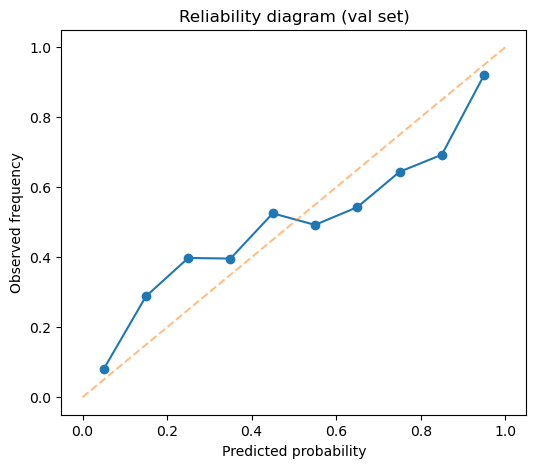

In [39]:
import matplotlib.pyplot as plt # Plotting library

probs = preds_val # Stores predicted probabilities from validation set (uses validation probabilities from the LightGBM classifier)
bins = np.linspace(0, 1, 11) # 10 probability bins: creates 11 evenly spaced values between 0 & 1
bin_idx = np.digitize(probs, bins) - 1  # Assigns each probability to a bin index (subtracting 1 to make indices start from 0)
bin_centers = (bins[:-1] + bins[1:]) / 2  # Computes midpoint of each bin for plotting
bin_true = [] # Empty list to store observed true outcome frequencies for each bin

# Loop through each bin
for i in range(len(bin_centers)):
    mask = bin_idx == i # Boolean mask selecting all predictions that fall into bin i
    # Calculates actual observed frequency in this bin & if empty bin store as nan
    bin_true.append(y_val[mask].mean() if mask.any() else np.nan)

plt.figure(figsize=(6,5))  # Set figure size
plt.plot(bin_centers, bin_true, marker='o') # Plots predicted probabilities (x-axis) vs observed frequencies (y-axis)
plt.plot([0,1],[0,1],'--', alpha=0.5)  # Plots diagonal line representing perfect calibration
plt.xlabel('Predicted probability')  # Label the x-axis
plt.ylabel('Observed frequency') # Labels the y-axis
plt.title('Reliability diagram (val set)')  # Add title
plt.show() # Show plot

**Result Explanation:** *It is important because our project is not only about choosing winners, it is also about giving meaningful probabilities. In sports analytics, calibration matters for decision support and model trustworthiness.*

## 10. Save models and scalers

In [41]:
MODEL_DIR = Path('models') # Path to model output folder
MODEL_DIR.mkdir(exist_ok=True) # Create folder if it does not exist

joblib.dump(scaler, MODEL_DIR / 'scaler.joblib') # Save fitted Standard Scaler
joblib.dump(log, MODEL_DIR / 'logistic.joblib') # Save Logistic Regression Model
joblib.dump(features_logistic, MODEL_DIR / 'logistic_features.joblib')
joblib.dump(features, MODEL_DIR / 'lgb_classifier_features.joblib')

bst.save_model(str(MODEL_DIR / 'lgb_model.txt'), num_iteration=bst.best_iteration) # Save LightGBM Classifier

joblib.dump(rank_features, MODEL_DIR / 'rank_features.joblib') # Save ranking feature list

ranker.save_model(str(MODEL_DIR / 'lgb_lambdarank.txt'), num_iteration=ranker.best_iteration) # Save LambdaRank Model

print('Saved models to', MODEL_DIR) # Confirm saving completed

Saved models to models
